In [31]:
# Loading libraries

import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
import statsmodels
import statsmodels.api as sm
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [32]:
#downloading dollar data
dxy = yf.download(
    "DX-Y.NYB",
    start="2010-01-01",
    progress=False
)


C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Temp\ipykernel_18212\1922216312.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dxy = yf.download(


In [33]:
print(dxy.head())
print(dxy.columns)


Price           Close       High        Low       Open   Volume
Ticker       DX-Y.NYB   DX-Y.NYB   DX-Y.NYB   DX-Y.NYB DX-Y.NYB
Date                                                           
2010-01-04  77.529999  78.190002  77.260002  77.930000        0
2010-01-05  77.620003  77.709999  77.089996  77.370003        0
2010-01-06  77.489998  78.000000  77.360001  77.650002        0
2010-01-07  77.910004  78.080002  77.300003  77.370003        0
2010-01-08  77.470001  78.190002  77.349998  77.980003        0
MultiIndex([( 'Close', 'DX-Y.NYB'),
            (  'High', 'DX-Y.NYB'),
            (   'Low', 'DX-Y.NYB'),
            (  'Open', 'DX-Y.NYB'),
            ('Volume', 'DX-Y.NYB')],
           names=['Price', 'Ticker'])


In [ ]:
price = dxy['Close']

# Ensure datetime index
price.index = pd.to_datetime(price.index)


# Drop missing values
price = price.dropna()


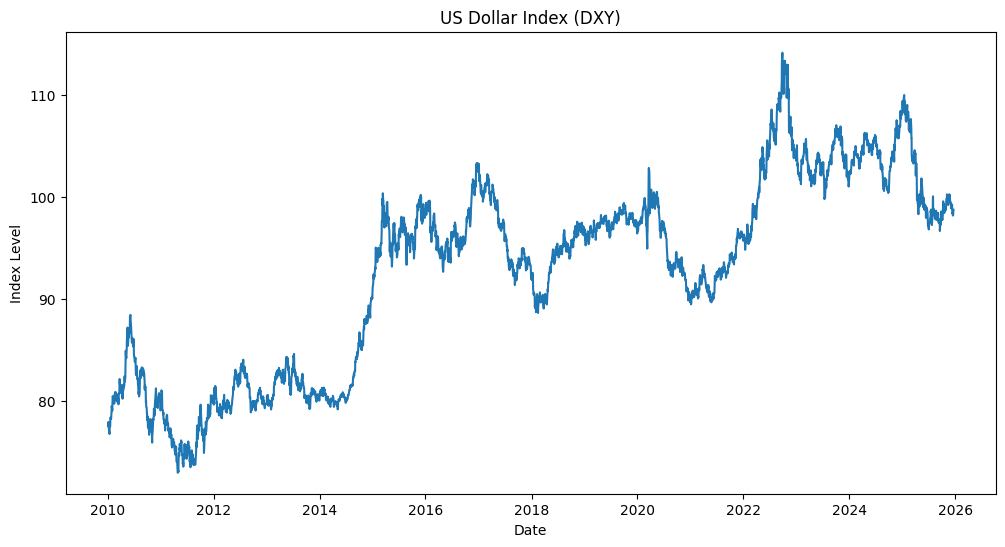

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(price.index, price.values)
plt.title("US Dollar Index (DXY)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.show()


In [40]:
print(price.head())




Ticker       DX-Y.NYB
Date                 
2010-01-04  77.529999
2010-01-05  77.620003
2010-01-06  77.489998
2010-01-07  77.910004
2010-01-08  77.470001


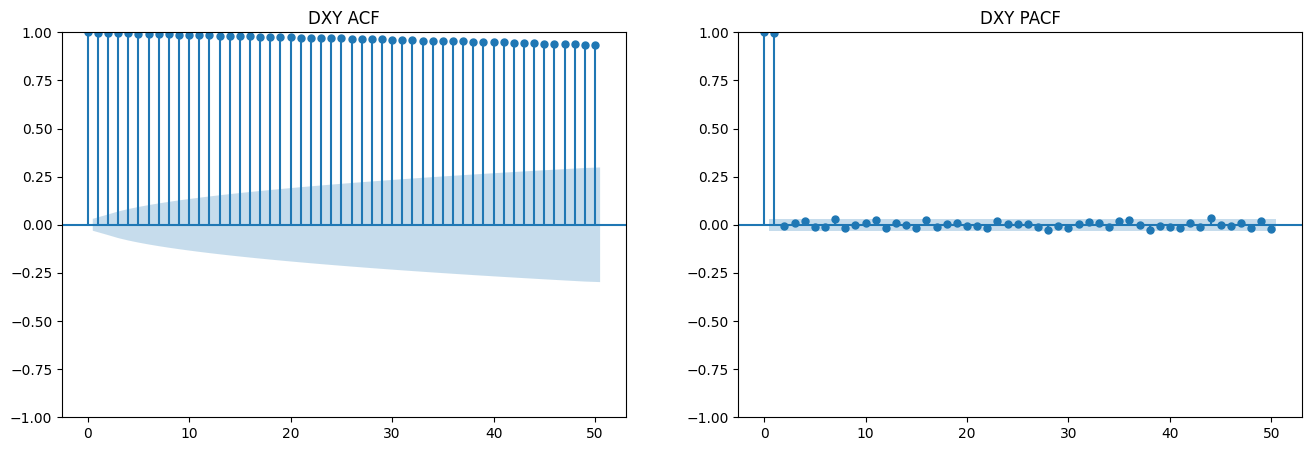

In [41]:
# plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sm.graphics.tsa.plot_acf(price, title="DXY ACF", lags=50, ax=ax1)
sm.graphics.tsa.plot_pacf(price, title="DXY PACF", lags=50, ax=ax2)
plt.show()

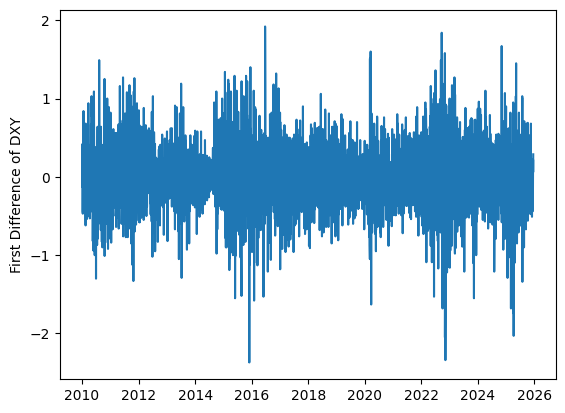

In [42]:
# Plot of First Differencing of DXY
plt.plot(price.diff().dropna())
plt.ylabel("First Difference of DXY")
plt.show()

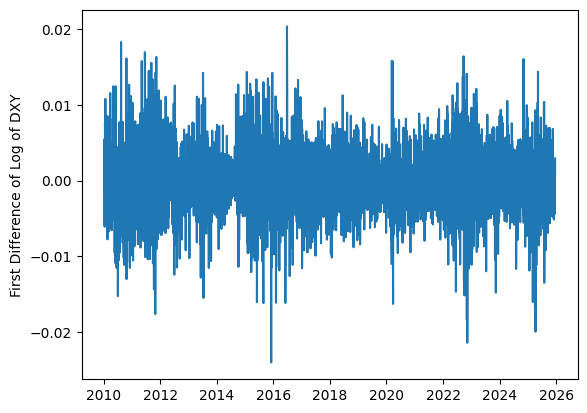

In [43]:
# Plot First Differencing of Log of DXY
plt.plot(np.log(price).diff().dropna())
plt.ylabel("First Difference of Log of DXY")
plt.show()

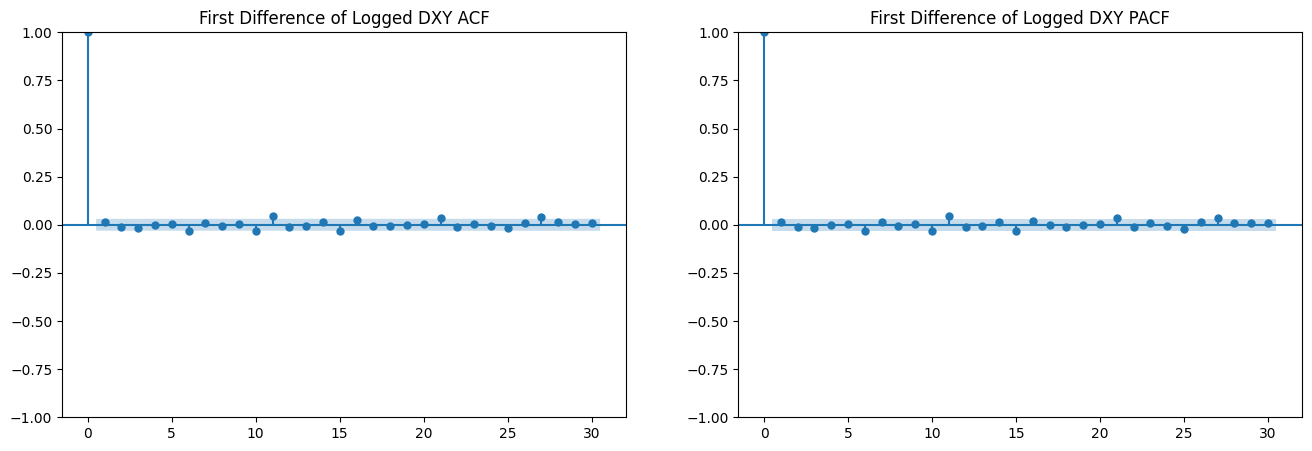

In [44]:
# ACF and PACF Plots for First Difference of Logged Google Stock Price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sm.graphics.tsa.plot_acf(
    np.log(price).diff().dropna(),
    title="First Difference of Logged DXY ACF",
    lags=30,
    ax=ax1,
)
sm.graphics.tsa.plot_pacf(
    np.log(price).diff().dropna(),
    title="First Difference of Logged DXY PACF",
    lags=30,
    ax=ax2,
)
plt.show()

In [45]:
# Efficient ARIMA model Selection
mod_can_auto = auto_arima(
    np.log(price).dropna(),  # stepwise=False,
    start_p=0,
    start_d=0,
    start_q=0,
    max_p=3,
    max_d=3,
    max_q=3,
    trace=True,
    with_intercept=False,
    return_valid_fits=True,
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-32055.962, Time=2.71 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-32054.669, Time=0.39 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-32054.685, Time=0.41 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-32052.583, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-32054.688, Time=0.62 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 5.748 seconds


In [46]:
# Best ARIMA Model for DXY
mod_can_a = SARIMAX(
    np.log(price), order=(0, 1, 0), trend="c").fit()  # This is the best model in Python implementation
print(mod_can_a.summary())

C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               DX-Y.NYB   No. Observations:                 4018
Model:               SARIMAX(0, 1, 0)   Log Likelihood               16029.344
Date:                Mon, 22 Dec 2025   AIC                         -32054.688
Time:                        00:01:35   BIC                         -32042.091
Sample:                             0   HQIC                        -32050.224
                               - 4018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   6.013e-05   7.06e-05      0.852      0.394   -7.83e-05       0.000
sigma2      2.002e-05   3.37e-07     59.490      0.000    1.94e-05    2.07e-05
Ljung-Box (L1) (Q):                   0.69   Jarque-

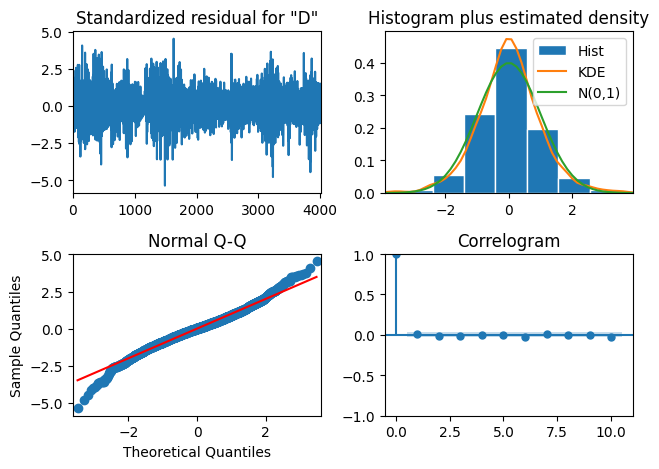

In [54]:
# Diagnostic Report for ARIMA(0,1,0) Model
mod_can_a.plot_diagnostics()

plt.tight_layout()
plt.show()

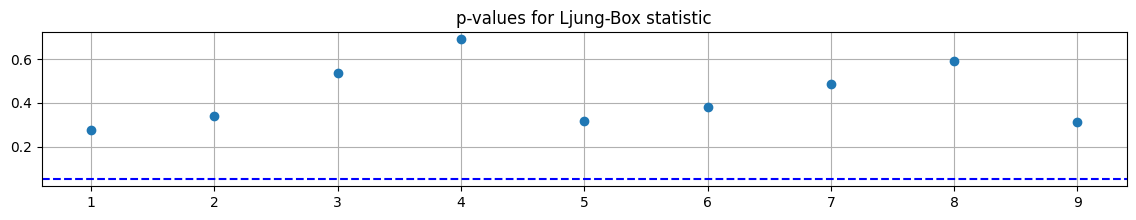

In [55]:
# Ljung-Box test for no serial correlation of standardized residuals
lb_test = mod_can_a.test_serial_correlation(
    method="ljungbox", df_adjust=True, lags=None
)

# plot Ljung-Box test p-values and 0.05 significance line
plt.figure(figsize=(14, 2))
plt.plot(lb_test[0][1], linestyle="", marker="o")
plt.axhline(y=0.05, color="blue", linestyle="--")
plt.title("p-values for Ljung-Box statistic")
plt.grid()
plt.show()

C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


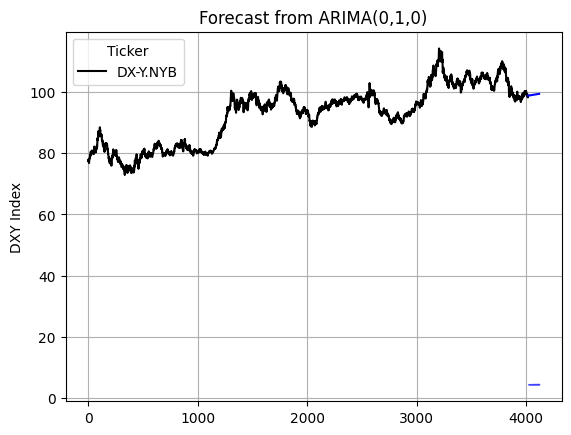

In [63]:
# Plot Dollar data
ffx = price.copy()
ffx.index = [i for i in range(len(ffx))]  # Set numeric index
ffx.plot(ylabel="DXY Index", title="Forecast from ARIMA(0,1,0)", color="k")

# get forecast data for next 100 steps
forecast = mod_can_a.get_forecast(steps=100)
forecast_mean = np.exp(forecast.predicted_mean)  # mean of forecast data
conf_int95 = forecast.conf_int(alpha=0.05)  # 95% confidence interval
conf_int80 = forecast.conf_int(alpha=0.2)  # 80% confidence interval

# plot mean forecast and 95% and 80% confidence intervals
plt.plot(forecast_mean, c="b")
plt.fill_between(
    conf_int95.index,
     conf_int95.iloc[:, 0],   # lower bound
    conf_int95.iloc[:, 1],   # upper bound
    color="b",
    alpha=0.3,
)
plt.fill_between(
    conf_int80.index,
    conf_int80.iloc[:, 0],
    conf_int80.iloc[:, 1],
    color="b",
    alpha=0.5,
)
plt.grid()
plt.show()

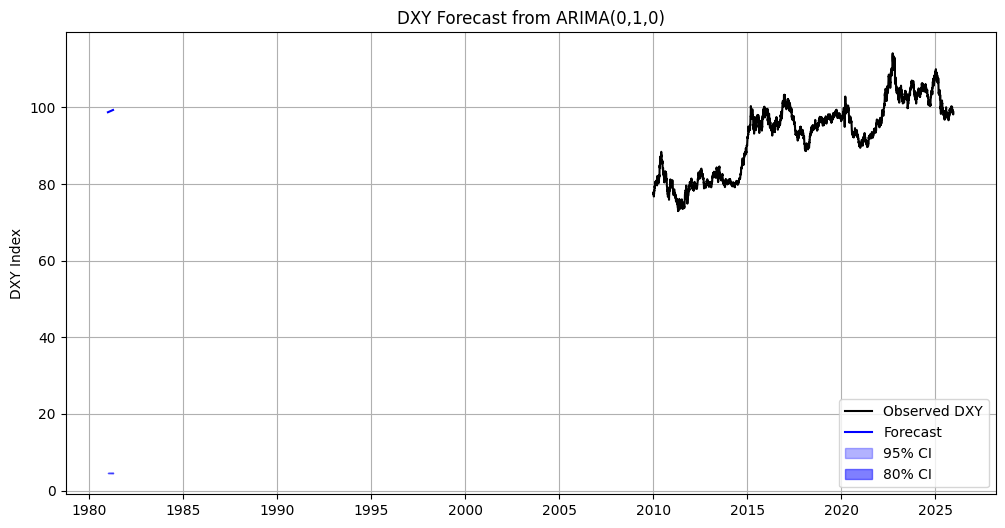

In [59]:
plt.figure(figsize=(12, 6))

# Plot observed data
plt.plot(price.index, price, label="Observed DXY", color="k")

# Plot forecast mean
plt.plot(forecast_mean.index, forecast_mean, color="b", label="Forecast")

# 95% confidence interval
plt.fill_between(
    conf_int95.index,
    conf_int95.iloc[:, 0],   # lower bound
    conf_int95.iloc[:, 1],   # upper bound
    color="b",
    alpha=0.3,
    label="95% CI"
)

# 80% confidence interval
plt.fill_between(
    conf_int80.index,
    conf_int80.iloc[:, 0],
    conf_int80.iloc[:, 1],
    color="b",
    alpha=0.5,
    label="80% CI"
)

plt.title("DXY Forecast from ARIMA(0,1,0)")
plt.ylabel("DXY Index")
plt.legend()
plt.grid()
plt.show()


C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency i

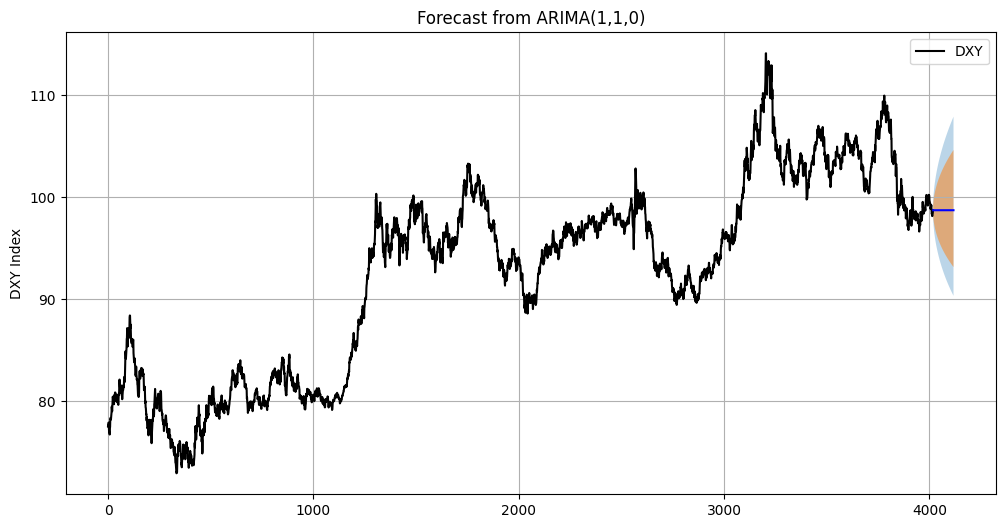

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Log transform
y = np.log(price)

# Fit ARIMA(1,1,0)
model = ARIMA(y, order=(1, 1, 0))
res = model.fit()

# Numeric index
y_plot = y.copy()
y_plot.index = range(len(y_plot))

# Forecast
h = 100
fc = res.get_forecast(steps=h)

mean_fc = np.exp(fc.predicted_mean)
ci95 = np.exp(fc.conf_int(alpha=0.05))
ci80 = np.exp(fc.conf_int(alpha=0.2))

fc_index = range(len(y_plot), len(y_plot) + h)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_plot.index, np.exp(y_plot), color="k", label="DXY")

plt.plot(fc_index, mean_fc, color="b")

plt.fill_between(fc_index, ci95.iloc[:, 0], ci95.iloc[:, 1], alpha=0.3)
plt.fill_between(fc_index, ci80.iloc[:, 0], ci80.iloc[:, 1], alpha=0.5)

plt.title("Forecast from ARIMA(1,1,0)")
plt.ylabel("DXY Index")
plt.legend()
plt.grid()
plt.show()
